In [1]:
!pip install numpy pandas scipy pywavelets scikit-learn xgboost seaborn

In [2]:
import os
import numpy as np
import pandas as pd
import pywt

from scipy.signal import ellip, filtfilt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.utils import resample, shuffle

from sklearn.model_selection import KFold, LeaveOneGroupOut

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
DATASET_PATH = "dataset-processed"

FS = 200
EPOCH_SECONDS = 8
EPOCH_SAMPLES = FS * EPOCH_SECONDS

LABEL_MAP = {"C":0,"F":1,"A":1}

FEATURE_TYPES = ["LBP","AE","RMS"]

In [4]:
def bandpass_filter(signal):

    nyq = 0.5 * FS
    low = 0.1 / nyq
    high = 60 / nyq

    b,a = ellip(4,1,40,[low,high],btype="band")

    return filtfilt(b,a,signal)

In [5]:
def extract_feature(epoch,feature_type):

    coeffs = pywt.wavedec(epoch,"db4",level=4)

    features=[]

    for c in coeffs:

        if feature_type=="LBP":
            val=np.log(np.mean(c**2)+1e-10)

        elif feature_type=="AE":
            val=np.sum(c**2)

        elif feature_type=="RMS":
            val=np.sqrt(np.mean(c**2))

        features.append(val)

    return features

In [6]:
def build_dataset(feature_type):

    X=[]
    y=[]
    groups=[]

    subjects=sorted(os.listdir(DATASET_PATH))

    for subject in subjects:

        subject_path=os.path.join(DATASET_PATH,subject)

        if not os.path.isdir(subject_path):
            continue

        exports=os.path.join(subject_path,"exports")

        eeg_file=None
        meta_file=None

        for f in os.listdir(exports):

            if "channels_timeseries" in f:
                eeg_file=f

            if "metadata" in f:
                meta_file=f

        eeg_df=pd.read_csv(os.path.join(exports,eeg_file))
        meta_df=pd.read_csv(os.path.join(exports,meta_file))

        label_raw=meta_df["group_code"].iloc[0]
        label=LABEL_MAP[label_raw]

        if "time" in eeg_df.columns:
            eeg_df=eeg_df.drop(columns=["time"])

        channels=eeg_df.columns

        length=len(eeg_df)
        n_epochs=length//EPOCH_SAMPLES

        for i in range(n_epochs):

            start=i*EPOCH_SAMPLES
            end=(i+1)*EPOCH_SAMPLES

            epoch_features=[]

            for ch in channels:

                signal=eeg_df[ch].values[start:end]

                signal=bandpass_filter(signal)

                feats=extract_feature(signal,feature_type)

                epoch_features.extend(feats)

            X.append(epoch_features)
            y.append(label)
            groups.append(subject)

    return np.array(X),np.array(y),np.array(groups)

In [7]:
def balance_data(X,y):

    df=pd.DataFrame(X)
    df["label"]=y

    class0=df[df.label==0]
    class1=df[df.label==1]

    if len(class0)<len(class1):

        class1_down=resample(
            class1,
            replace=False,
            n_samples=len(class0),
            random_state=42
        )

        df_bal=pd.concat([class0,class1_down])

    else:

        class0_down=resample(
            class0,
            replace=False,
            n_samples=len(class1),
            random_state=42
        )

        df_bal=pd.concat([class0_down,class1])

    y_bal=df_bal["label"].values
    X_bal=df_bal.drop(columns=["label"]).values

    return X_bal,y_bal

In [8]:
models={

"SVM":SVC(kernel="rbf",class_weight="balanced"),

"KNN":KNeighborsClassifier(n_neighbors=7),

"RandomForest":RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced"
),

"XGBoost":XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss"
)

}

In [9]:
def train_model_kfold(name, model, X, y):

    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    scores = []
    all_true = []
    all_pred = []

    for train_idx, test_idx in kf.split(X):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # balance training data
        X_train, y_train = balance_data(X_train, y_train)

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)

        scores.append(acc)

        all_true.extend(y_test)
        all_pred.extend(preds)

    mean_acc = np.mean(scores)
    std_acc = np.std(scores)

    print(f"{name} → {mean_acc:.4f} ± {std_acc:.4f}")

    cm = confusion_matrix(all_true, all_pred)

    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")
    plt.title(name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return mean_acc, std_acc


Feature: LBP
SVM → 0.8974 ± 0.0067


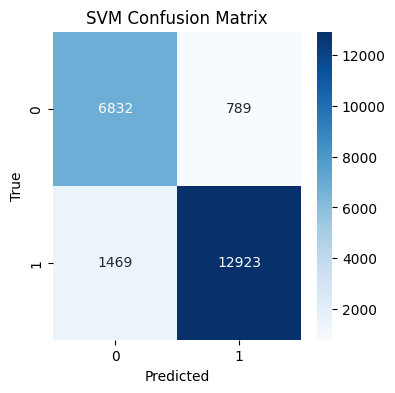

KNN → 0.9361 ± 0.0035


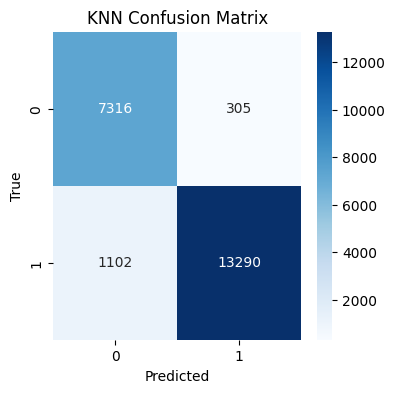

RandomForest → 0.9879 ± 0.0017


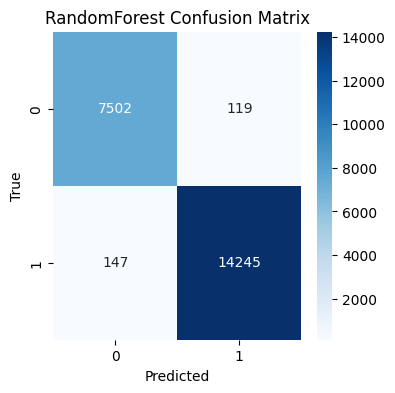

XGBoost → 0.9901 ± 0.0011


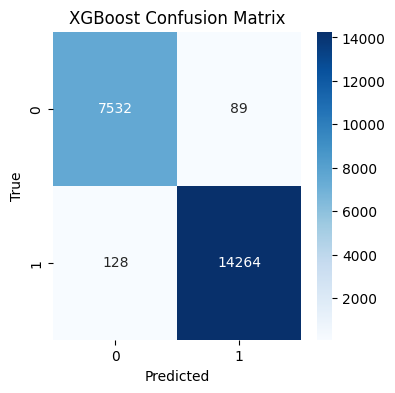


Feature: AE
SVM → 0.5241 ± 0.0151


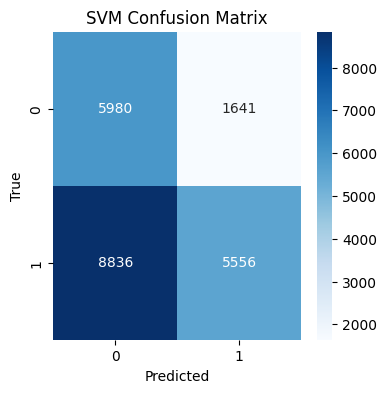

KNN → 0.6459 ± 0.0154


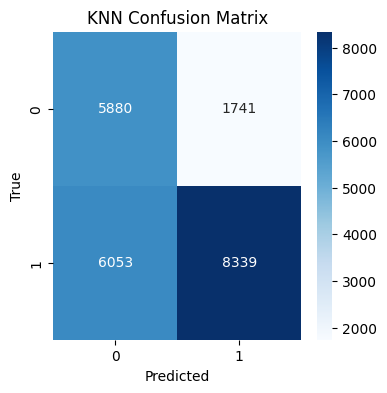

RandomForest → 0.9881 ± 0.0021


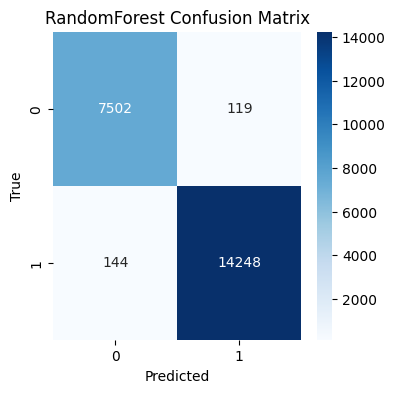

XGBoost → 0.9901 ± 0.0014


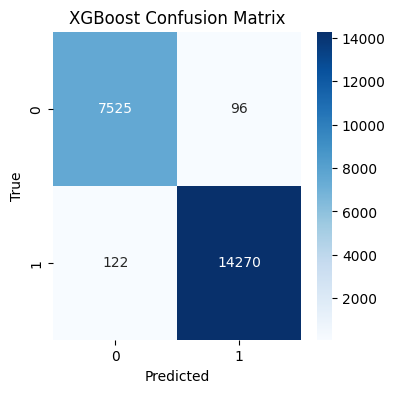


Feature: RMS
SVM → 0.8297 ± 0.0081


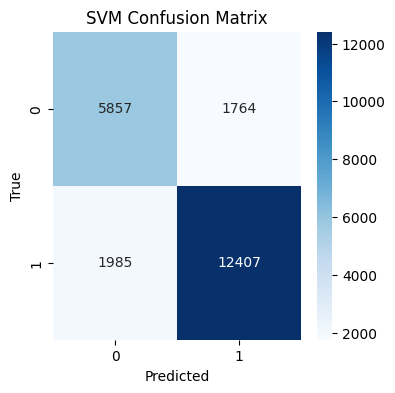

KNN → 0.8917 ± 0.0076


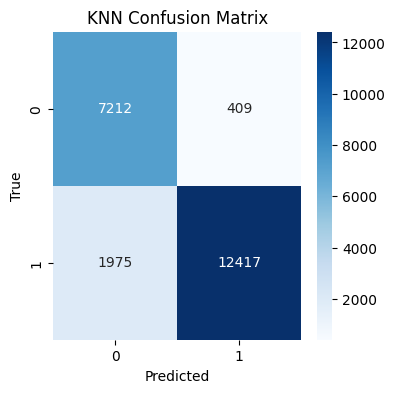

RandomForest → 0.9881 ± 0.0021


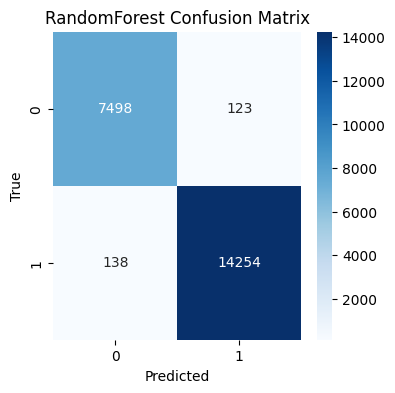

XGBoost → 0.9901 ± 0.0010


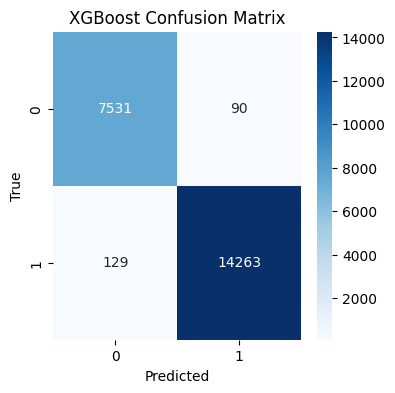

In [10]:
results = []

for feature in FEATURE_TYPES:

    print("\n============================")
    print("Feature:", feature)
    print("============================")

    X, y, groups = build_dataset(feature)

    y = y.astype(int)

    # shuffle only for k-fold
    X, y, groups = shuffle(X, y, groups, random_state=42)

    for name, model in models.items():

        mean_acc, std_acc = train_model_kfold(name, model, X, y)

        results.append({
            "Feature": feature,
            "Model": name,
            "Accuracy": mean_acc,
            "Std": std_acc
        })

In [11]:
results_df = pd.DataFrame(results)

print("10-Fold Cross Validation Results")

display(results_df)

10-Fold Cross Validation Results


,Feature,Model,Accuracy,Std
0,LBP,SVM,0.897424,0.006726
1,LBP,KNN,0.936084,0.003466
2,LBP,RandomForest,0.987916,0.001750
3,LBP,XGBoost,0.990142,0.001057
4,AE,SVM,0.524055,0.015098
5,AE,KNN,0.645938,0.015438
6,AE,RandomForest,0.988053,0.002131
7,AE,XGBoost,0.990097,0.001376
8,RMS,SVM,0.829691,0.008076
9,RMS,KNN,0.891702,0.007608


# Later Code

In [12]:
def train_model_loso(name, model, X, y, groups):

    logo = LeaveOneGroupOut()

    scores = []

    for train_idx, test_idx in logo.split(X, y, groups):

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # balance training data
        X_train, y_train = balance_data(X_train, y_train)

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)

        scores.append(acc)

    mean_acc = np.mean(scores)
    std_acc = np.std(scores)

    return mean_acc, std_acc

In [13]:
loso_results = []

for feature in FEATURE_TYPES:

    print("\n============================")
    print("LOSO Feature:", feature)
    print("============================")

    X, y, groups = build_dataset(feature)

    y = y.astype(int)

    # IMPORTANT: do NOT shuffle for LOSO

    for name, model in models.items():

        mean_acc, std_acc = train_model_loso(name, model, X, y, groups)

        print(f"{name} → {mean_acc:.4f} ± {std_acc:.4f}")

        loso_results.append({
            "Feature": feature,
            "Model": name,
            "Accuracy": mean_acc,
            "Std": std_acc
        }) 


LOSO Feature: LBP
SVM → 0.7115 ± 0.3079
KNN → 0.5525 ± 0.2882
RandomForest → 0.6081 ± 0.3652
XGBoost → 0.6194 ± 0.3620

LOSO Feature: AE
SVM → 0.4436 ± 0.3523
KNN → 0.4655 ± 0.2340
RandomForest → 0.6066 ± 0.3662
XGBoost → 0.6209 ± 0.3582

LOSO Feature: RMS
SVM → 0.7317 ± 0.3159
KNN → 0.5288 ± 0.2705
RandomForest → 0.5987 ± 0.3695
XGBoost → 0.6244 ± 0.3604


In [14]:
loso_df = pd.DataFrame(loso_results)

print("Leave-One-Subject-Out Results")

display(loso_df)

Leave-One-Subject-Out Results


,Feature,Model,Accuracy,Std
0,LBP,SVM,0.711450,0.307890
1,LBP,KNN,0.552485,0.288209
2,LBP,RandomForest,0.608082,0.365247
3,LBP,XGBoost,0.619402,0.362050
4,AE,SVM,0.443587,0.352301
5,AE,KNN,0.465545,0.233984
6,AE,RandomForest,0.606639,0.366216
7,AE,XGBoost,0.620933,0.358244
8,RMS,SVM,0.731661,0.315900
9,RMS,KNN,0.528822,0.270526
